# Phase 5: predictive maintenance, remaining useful life

A model that predicts how many operating cycles a jet engine has left before it fails, using the NASA C-MAPSS FD001 dataset, the standard public benchmark for this problem. This phase is deliberately separate from the hoist twin, its own dataset, its own folder (`src/pdm/`), and its own notebook. The point is to learn the predictive maintenance workflow properly on data everyone in the field recognises, before Phase 6 connects the technique back to the winder.

Three models are built, each a step up in sophistication: a linear regression baseline, an XGBoost regressor, and a small LSTM that reads the raw sensor history directly. All the reasoning behind the choices below, the RUL cap, the rolling and lag features, the validation split, the scoring function, is written up in `phase5_plan.md`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pdm.data import (
    OPERATIONAL_SETTING_COLS,
    SENSOR_COLS,
    build_inference_windows,
    build_training_windows,
    compute_rul,
    load_raw,
    train_validation_split,
)
from pdm.features import add_rolling_and_lag_features, drop_constant_sensors, feature_matrix_columns
from pdm.models import RulLSTM, predict_lstm, train_linear_baseline, train_lstm, train_xgboost
from pdm.evaluate import comparison_table, compute_shap_values, predicted_vs_true_plot, shap_importance_table

RUL_CAP = 125
data = load_raw(str(PROJECT_ROOT / "data" / "raw"))
train_df = compute_rul(data["train"], cap=RUL_CAP)
test_df = data["test"]
rul_df = data["rul"]

print(f"train: {train_df['unit_number'].nunique()} engines, {len(train_df)} rows")
print(f"test:  {test_df['unit_number'].nunique()} engines, {len(test_df)} rows")
print(f"RUL_FD001.txt: {len(rul_df)} rows")

/home/duytrangiale/HoistDigiTwin/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train: 100 engines, 20631 rows
test:  100 engines, 13096 rows
RUL_FD001.txt: 100 rows


## The remaining useful life label

Training trajectories run all the way to failure, so each engine's own last recorded cycle is its failure point, and RUL simply counts down from there. Capped at 125 cycles: a fresh engine is not meaningfully "500 cycles from failure" versus "480," degradation has not started yet, only the decline near failure is real signal worth learning. This is the standard convention in the C-MAPSS literature, not a number invented for this project.

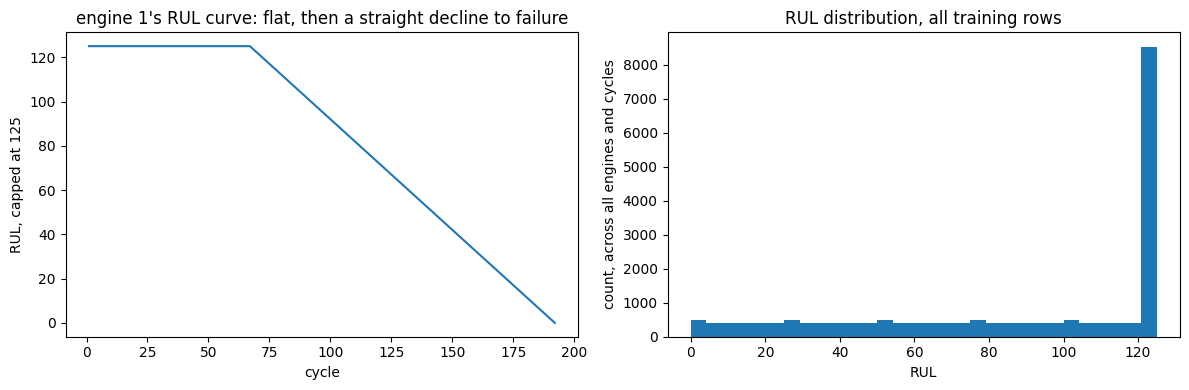

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample_engine = train_df[train_df["unit_number"] == 1].sort_values("time_in_cycles")
axes[0].plot(sample_engine["time_in_cycles"], sample_engine["RUL"])
axes[0].set_xlabel("cycle")
axes[0].set_ylabel("RUL, capped at 125")
axes[0].set_title("engine 1's RUL curve: flat, then a straight decline to failure")

axes[1].hist(train_df["RUL"], bins=30)
axes[1].set_xlabel("RUL")
axes[1].set_ylabel("count, across all engines and cycles")
axes[1].set_title("RUL distribution, all training rows")

plt.tight_layout()
plt.show()

## Feature engineering

FD001 has only one operating condition, so several sensors never move at all, there is nothing for them to vary with. Checked directly by variance, not a hard coded list, though the result should be close to what other analyses of this same subset find.

For the sensors that do vary, a 5 cycle rolling mean and standard deviation smooth out cycle to cycle noise, and lags of 1 and 2 cycles give a sense of recent direction. All of this is computed one engine at a time, an engine's rolling window or lag never reaches into a different engine's history.

In [3]:
surviving_sensors = drop_constant_sensors(train_df, SENSOR_COLS)
dropped_sensors = [c for c in SENSOR_COLS if c not in surviving_sensors]
print(f"dropped as constant ({len(dropped_sensors)}): {dropped_sensors}")
print(f"kept ({len(surviving_sensors)}): {surviving_sensors}")

train_featured = add_rolling_and_lag_features(train_df, surviving_sensors, window=5, lags=(1, 2))
feature_cols = feature_matrix_columns(surviving_sensors, lags=(1, 2))
print(f"\n{len(feature_cols)} feature columns for the linear and XGBoost models")

dropped as constant (6): ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
kept (15): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']



78 feature columns for the linear and XGBoost models


## Why the split is by engine, not by row

Shuffling rows at random and splitting would let a model see cycle 47 of an engine in training and cycle 48 of that same engine in validation. That is not testing whether the model generalises to a new engine, it is testing whether it recognised the same engine it already partly saw, which would look like clean generalisation while quietly being nothing of the sort.

The official test set already keeps this separation, its 100 engines are entirely different machines from the 100 training engines. But comparing the three models against each other during development needs its own held out engines too, so 20 of the 100 training engines are set aside here by unit number, kept completely out of fitting, and used only to compare the models before touching the official test set at all.

In [4]:
fit_units, val_units = train_validation_split(train_df, n_validation_engines=20, seed=42)
print(f"fitting on {len(fit_units)} engines, validating on {len(val_units)} held out engines")

fit_df = train_featured[train_featured["unit_number"].isin(fit_units)]
val_df = train_featured[train_featured["unit_number"].isin(val_units)]

X_fit, y_fit = fit_df[feature_cols], fit_df["RUL"]
X_val, y_val = val_df[feature_cols], val_df["RUL"]
print(f"fit rows: {len(X_fit)}, validation rows: {len(X_val)}")

fitting on 80 engines, validating on 20 held out engines
fit rows: 16738, validation rows: 3893


## Three models, increasing sophistication

Linear regression and XGBoost read the engineered features above, one row at a time. The LSTM instead reads a 30 cycle window of raw sensor values directly, no rolling or lag features, since learning the shape of the trajectory itself is the whole point of using a sequence model rather than another tree.

In [5]:
linear_model = train_linear_baseline(X_fit, y_fit)
xgb_model = train_xgboost(X_fit, y_fit)

raw_feature_cols = OPERATIONAL_SETTING_COLS + surviving_sensors
X_fit_seq, y_fit_seq = build_training_windows(fit_df, raw_feature_cols, rul_col="RUL", window_length=30)
X_val_seq, y_val_seq = build_training_windows(val_df, raw_feature_cols, rul_col="RUL", window_length=30)
print(f"LSTM training windows: {X_fit_seq.shape}, validation windows: {X_val_seq.shape}")

lstm_model, lstm_scaler, train_losses, val_losses = train_lstm(
    X_fit_seq, y_fit_seq, X_val_seq, y_val_seq, n_epochs=30, seed=42
)
best_epoch = int(np.argmin(val_losses)) + 1
print(f"LSTM training done, best validation epoch was {best_epoch} of {len(val_losses)}")

LSTM training windows: (14418, 30, 18), validation windows: (3313, 30, 18)


LSTM training done, best validation epoch was 13 of 30


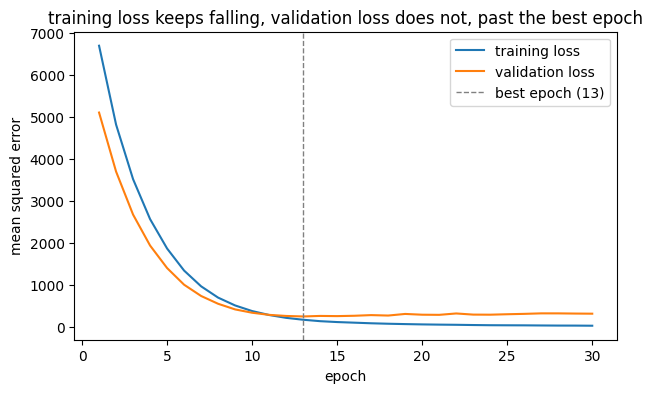

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(train_losses) + 1), train_losses, label="training loss")
ax.plot(range(1, len(val_losses) + 1), val_losses, label="validation loss")
ax.axvline(best_epoch, color="grey", linestyle="--", linewidth=1, label=f"best epoch ({best_epoch})")
ax.set_xlabel("epoch")
ax.set_ylabel("mean squared error")
ax.set_title("training loss keeps falling, validation loss does not, past the best epoch")
ax.legend()
plt.show()

## A quick check on the held out engines, before touching the official test set

This is the internal comparison used to sanity check the three models during development. The real, one time reported result is the official test set further down.

In [7]:
internal_results = {
    "linear regression": {"y_true": y_val, "y_pred": linear_model.predict(X_val)},
    "XGBoost": {"y_true": y_val, "y_pred": xgb_model.predict(X_val)},
    "LSTM": {"y_true": y_val_seq, "y_pred": predict_lstm(lstm_model, lstm_scaler, X_val_seq)},
}
comparison_table(internal_results)

,RMSE,C-MAPSS score
model,,
linear regression,21.426826,49177.181465
XGBoost,18.844237,76306.207542
LSTM,15.494564,19257.621241


## The official test set, the real result

This is the one result that actually counts. 100 engines the models have never seen in training or validation. Each one was stopped at a random point before it failed, so we do not know from the data alone how close to breaking down it really was. `RUL_FD001.txt` gives us that answer directly, the true number of cycles each engine had left at the point we stopped watching it, in the same order the engines appear in `test_FD001.txt`. Checked directly against the raw file rather than assumed.

Each model gets exactly one prediction per engine, using only what was recorded up to the point it was cut off:
- Linear regression and XGBoost use that engine's last recorded row, which already carries its rolling averages and recent trend.
- The LSTM reads that engine's last 30 cycles as a sequence, since reading the shape of a trajectory is the whole reason to use it. An engine with fewer than 30 recorded cycles would have its missing early cycles filled with zeros rather than being skipped, since every one of the 100 needs a prediction to line up against `RUL_FD001.txt`. None of FD001's test engines are actually that short, so this never triggers here.

In [8]:
test_featured = add_rolling_and_lag_features(test_df, surviving_sensors, window=5, lags=(1, 2))
last_row_per_engine = test_featured.sort_values("time_in_cycles").groupby("unit_number").tail(1)
last_row_per_engine = last_row_per_engine.sort_values("unit_number")

y_true_test = rul_df["RUL"].to_numpy()
X_test_flat = last_row_per_engine[feature_cols]

X_test_seq, test_units = build_inference_windows(test_df, raw_feature_cols, window_length=30)
assert test_units == sorted(test_units), "test engines must be in ascending order to match RUL_FD001.txt"

test_results = {
    "linear regression": {"y_true": y_true_test, "y_pred": linear_model.predict(X_test_flat)},
    "XGBoost": {"y_true": y_true_test, "y_pred": xgb_model.predict(X_test_flat)},
    "LSTM": {"y_true": y_true_test, "y_pred": predict_lstm(lstm_model, lstm_scaler, X_test_seq)},
}
comparison_table(test_results)

,RMSE,C-MAPSS score
model,,
linear regression,21.957750,1466.542266
XGBoost,18.916316,1037.085247
LSTM,14.648281,295.916478


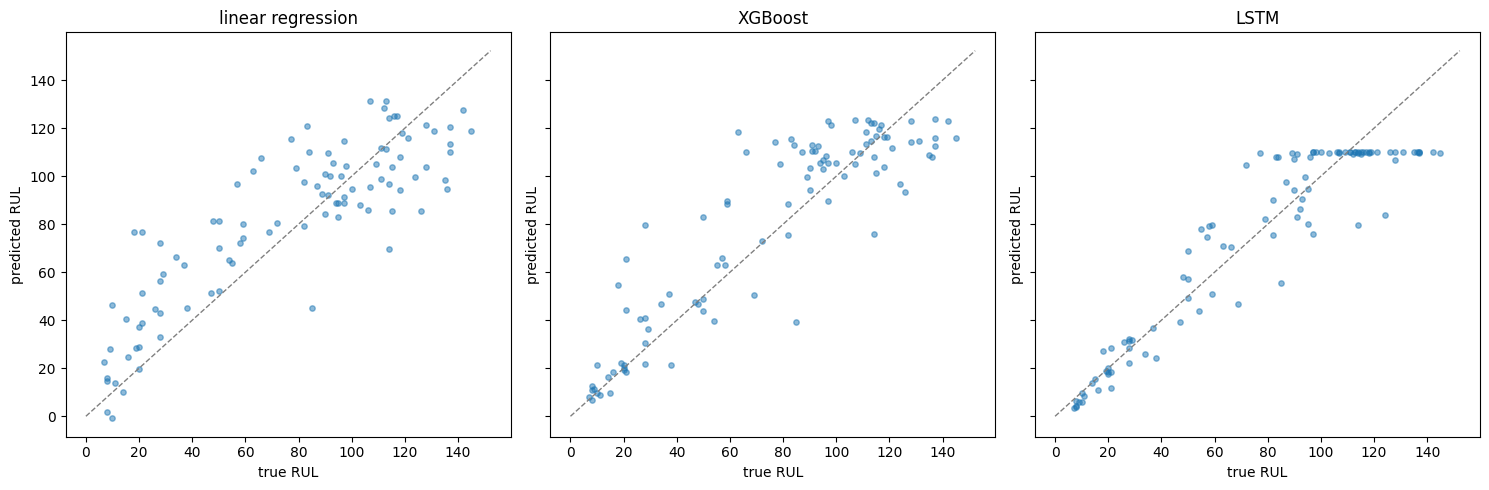

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, (name, r) in zip(axes, test_results.items()):
    predicted_vs_true_plot(r["y_true"], r["y_pred"], title=name, ax=ax)
plt.tight_layout()
plt.show()

## Reading the three plots

Each dot is one engine. True remaining life is on the x axis, the model's guess is on the y axis. A perfect model would place every dot exactly on the grey diagonal line. A dot above the line is a late guess, the model promised more life than the engine actually had, the dangerous kind of mistake. A dot below the line is an early guess, too cautious, but safe.

Linear regression and XGBoost both show a wide, noisy scatter around the diagonal across the whole range. The LSTM's dots track the diagonal much more closely for engines with less than about 60 cycles left, which is the main reason its RMSE and C-MAPSS score both beat the other two by so much.

**The flat line of dots near the top of the LSTM panel is a real limit of the model, not a plotting mistake.** Checking the actual numbers behind it: for every engine whose true remaining life is above roughly 60 to 65 cycles, the LSTM predicts almost exactly the same number, about 79, whether the true answer is 70 or 145. That number is not arbitrary, it is close to the average remaining life across the entire training set.

Here is why that happens. Early in an engine's life it is still healthy, and a healthy engine's last 30 cycles of sensor readings look much like any other healthy engine's, there is no visible sign yet of how close it actually is to failure. The model was trained to minimise squared error, and when it genuinely cannot tell two healthy looking engines apart, the safest guess is the average outcome across all of them, not a confident but unsupported number. So it falls back to that average, which is exactly what creates the flat line.

This is a known pattern for models trained this way, not a bug specific to this LSTM, and it matters less than it first looks. It only shows up for engines that are still healthy and in no danger of failing soon. The engines that actually matter for a maintenance decision, the ones getting close to failure, are exactly where the LSTM's dots hug the diagonal and where it beats the other two models most clearly.

## Which sensors actually drive the prediction

The question a mining stakeholder always asks next: not just which sensor matters, but which direction it pushes the answer, does a high reading mean more time left or less. SHAP answers both at once. Plain feature importance from XGBoost only answers the first.

                   feature  mean_abs_shap
0   sensor_11_rolling_mean       7.684355
1    sensor_4_rolling_mean       7.108874
2    sensor_9_rolling_mean       5.630451
3   sensor_15_rolling_mean       5.311502
4   sensor_14_rolling_mean       2.059543
5    sensor_2_rolling_mean       1.934901
6    sensor_3_rolling_mean       1.658876
7   sensor_21_rolling_mean       1.395738
8   sensor_20_rolling_mean       1.045453
9   sensor_12_rolling_mean       0.939444
10   sensor_8_rolling_mean       0.642310
11  sensor_17_rolling_mean       0.630635
12  sensor_13_rolling_mean       0.612744
13                sensor_7       0.554117
14   sensor_13_rolling_std       0.460985



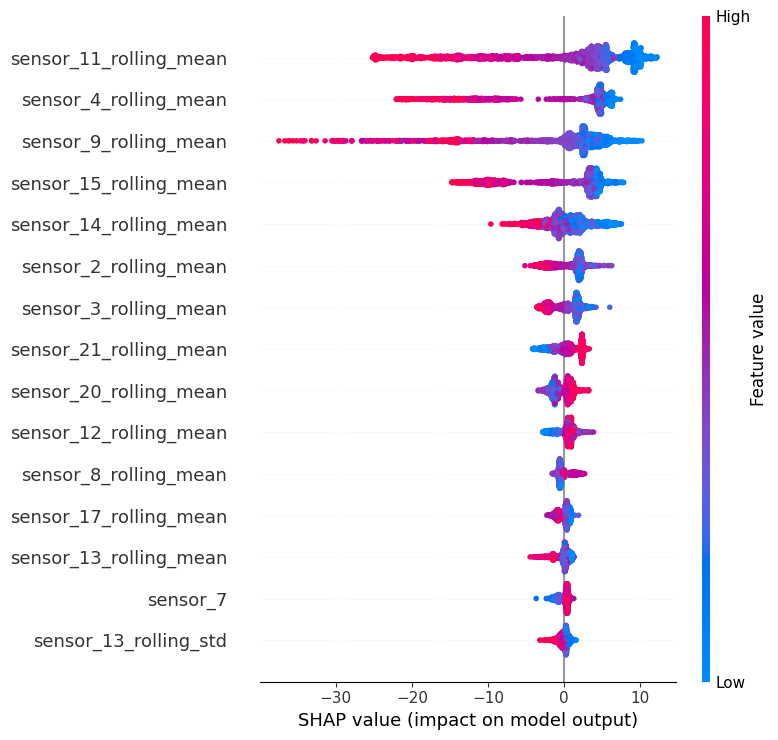

In [10]:
import shap

shap_values = compute_shap_values(xgb_model, X_fit, sample_size=2000, seed=42)
top_features = shap_importance_table(shap_values, n_top=15)
print(top_features)
print()

shap.summary_plot(shap_values, plot_type="dot", max_display=15, show=False)
plt.tight_layout()
plt.show()

## What this phase actually found

**The three models line up exactly as expected, on the result that counts.** On the official test set, each step up in sophistication is also a step up in accuracy: linear regression 21.96 RMSE, XGBoost 18.92, the LSTM 14.65. The C-MAPSS score, which punishes a late warning far more than an early one, agrees, dropping from about 1,467 to 1,037 to 296 in the same order. Both ways of measuring this point to the same answer here.

**RMSE and the C-MAPSS score do not always agree, and this project's own numbers prove it, not just the tiny example earlier.** On the held out validation engines used during development, XGBoost actually beat linear regression on RMSE, 18.84 against 21.43, but scored worse on the C-MAPSS metric, about 76,300 against 49,200. Checking why: XGBoost's single worst late prediction missed by 74 cycles against linear's worst of 64, and it had more than twice as many badly late predictions overall, 124 against 58 out of around 3,900 rows. So XGBoost is more accurate on a typical row, but has a longer tail of dangerously late guesses on this particular set of engines, exactly the failure mode the C-MAPSS score exists to catch and RMSE cannot see. This did not repeat on the official test set, likely because that comparison only judges one point per engine, right near the end of its life, while the validation comparison judges every cycle across each engine's full history, a genuinely different and broader test.

**The LSTM needed a fix to be trustworthy at all.** Its training loss fell for all 30 epochs, but validation loss stopped improving around epoch 13 and climbed back up after that, the model was starting to memorise the training engines rather than learn the general pattern. The version actually used here is from that best epoch, not the last one, which is why `train_lstm` tracks and returns it directly rather than whatever the model happens to look like when training stops.

**Sensor_11 and sensor_4 drive the prediction, by a clear margin.** SHAP's ranking puts them well ahead of everything else, consistent with published analyses of this same dataset that specifically call sensor_11 out as the dominant predictor. The summary plot above adds the part plain feature importance cannot: high recent readings from these sensors push the predicted remaining life down, exactly the direction a mining stakeholder would want confirmed, since a sensor that mattered but pushed the wrong way would be a red flag, not reassurance.

**What carries forward to Phase 6.** This dataset and the hoist twin are unrelated, jet engines are not a mine winder, but the technique is the one that matters: a degrading component's sensor history predicting how much life is left, checked honestly against data the model never trained on, with a scoring function that reflects the real cost of being wrong. Phase 6 connects that idea back to the winder itself, using it to decide when to intervene before a breakdown rather than after one.